# 15. Sensitivity Analysis: Multi-Year Weather & Cost Assumptions

Every model so far has been solved against a single weather year and a single set of cost
assumptions, as if both were known with certainty. Neither actually is: next year's wind and solar
output won't exactly repeat this year's, and a capital cost estimate made today is a snapshot, not a
guarantee. This model asks a different kind of question than every one before it — not "what's the
optimal answer," but **"how much does the optimal answer move if the inputs change?"**

The objective is to re-run the Model 13 capacity-expansion portfolio (extendable solar, wind, and
battery) against **two different weather years (2022 and 2025)**, compare how much the optimal
technology mix shifts between them, and then run a **parameter sweep** on solar's capital cost to see
how sensitive the optimal solar capacity is to that single assumption.

## Two different kinds of sensitivity
This notebook covers two distinct sources of uncertainty, and it's worth keeping them conceptually
separate:
- **Weather-year sensitivity**: holding every cost assumption fixed, how much does the optimal
  capacity mix change simply because 2022's wind and solar resource differs hour-by-hour from 2025's?
  A design that looks optimal against one year's weather may be noticeably sub-optimal against
  another's — this is why real capacity-expansion studies often solve against several historical
  weather years rather than just one.
- **Cost/parameter sensitivity**: holding the weather fixed, how much does the optimal answer move if
  a single cost assumption turns out to be wrong by some margin? This is answered by re-solving the
  same model repeatedly while sweeping one parameter, and plotting the result.

Both are answered the same way in PyPSA: **re-solve the model** under the changed input and compare.
There's no shortcut - sensitivity analysis in an LP context means literally running the optimization
again.


In [15]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('../')
from utils.viz_utils import set_nature_style
set_nature_style()


## Technical Parameters

The same technology parameters as Model 13 - extendable solar, wind, and battery, competing for
capital on a single electrical bus with a fixed industrial load and a two-directional grid
connection.


In [16]:
DISCOUNT_RATE = 0.04

def annuity(lifetime_years, investment, fom_percent):
    r = DISCOUNT_RATE
    crf = (r * (1 + r) ** lifetime_years) / ((1 + r) ** lifetime_years - 1)
    return investment * (crf + fom_percent / 100.0)

tech_param = {
    'solar_pv': {
        'p_nom_max': 30.0,
        'capital_cost': annuity(30, 550_000, 2.0),
        'marginal_cost': 0.0
    },
    'wind': {
        'p_nom_max': 30.0,
        'capital_cost': annuity(25, 1_100_000, 2.5),
        'marginal_cost': 0.0
    },
    'battery': {
        'p_nom_max': 10.0,
        'max_hours': 2.0,
        'capital_cost': annuity(15, 280_000 * 2, 1.5),
        'efficiency_store': 0.95,
        'efficiency_dispatch': 0.95
    },
    'market_grid': {
        'import_p_nom': 20.0,
        'export_p_nom': 18.0
    },
    'demand': {
        'day_load_mw': 8.0,
        'night_load_mw': 4.0
    }
}


## A Reusable Model-Building Function

Since this notebook solves the same network structure repeatedly - once per weather year, then
repeatedly again for the cost sweep - the network-building logic is wrapped in a single function
instead of being copy-pasted for each run. This is the same network as Model 13, just parameterized
so that the weather data and solar's capital cost multiplier can both be swapped between calls.


In [17]:
def build_and_solve(df_pv, df_wind, df_price, solar_capital_cost_multiplier=1.0):
    n = pypsa.Network()
    n.set_snapshots(df_pv.index)
    n.add("Bus", "electricity_bus")

    n.add("Generator", "Solar_PV", bus="electricity_bus",
          p_nom_extendable=True,
          p_nom_max=tech_param['solar_pv']['p_nom_max'],
          p_max_pu=df_pv['capacity_factor'],
          capital_cost=tech_param['solar_pv']['capital_cost'] * solar_capital_cost_multiplier,
          marginal_cost=tech_param['solar_pv']['marginal_cost'])

    n.add("Generator", "Wind", bus="electricity_bus",
          p_nom_extendable=True,
          p_nom_max=tech_param['wind']['p_nom_max'],
          p_max_pu=df_wind['capacity_factor'],
          capital_cost=tech_param['wind']['capital_cost'],
          marginal_cost=tech_param['wind']['marginal_cost'])

    n.add("Generator", "Grid_Import", bus="electricity_bus",
          p_nom=tech_param['market_grid']['import_p_nom'], marginal_cost=df_price['price'])

    n.add("Generator", "Grid_Export", bus="electricity_bus",
          p_nom=tech_param['market_grid']['export_p_nom'],
          p_min_pu=-1.0, p_max_pu=0.0, marginal_cost=df_price['price'])

    is_daytime = (n.snapshots.hour >= 8) & (n.snapshots.hour < 18)
    load_profile = np.where(is_daytime, tech_param['demand']['day_load_mw'], tech_param['demand']['night_load_mw'])
    n.add("Load", "Industrial_Load", bus="electricity_bus", p_set=pd.Series(load_profile, index=n.snapshots))

    n.add("StorageUnit", "Battery", bus="electricity_bus",
          p_nom_extendable=True,
          p_nom_max=tech_param['battery']['p_nom_max'],
          max_hours=tech_param['battery']['max_hours'],
          capital_cost=tech_param['battery']['capital_cost'],
          efficiency_store=tech_param['battery']['efficiency_store'],
          efficiency_dispatch=tech_param['battery']['efficiency_dispatch'],
          cyclic_state_of_charge=True)

    n.optimize(solver_name='highs')

    return {
        'solar_mw': n.generators.at['Solar_PV', 'p_nom_opt'],
        'wind_mw': n.generators.at['Wind', 'p_nom_opt'],
        'battery_mw': n.storage_units.at['Battery', 'p_nom_opt'],
        'objective': n.objective,
        'solar_generation_mwh': n.generators_t.p['Solar_PV'].sum(),
        'wind_generation_mwh': n.generators_t.p['Wind'].sum(),
        'grid_import_mwh': n.generators_t.p['Grid_Import'].sum()
    }


def load_year_data(year):
    df_pv = pd.read_csv(f'../data/processed/pv_{year}_hourly.csv', index_col='time', parse_dates=True)
    df_wind = pd.read_csv(f'../data/processed/wind_{year}_hourly.csv', index_col='time', parse_dates=True)
    df_price = pd.read_csv(f'../data/processed/electricity_price_{year}_hourly.csv', index_col='time', parse_dates=True)

    n_hours = len(df_pv)
    freq = '1h'
    start = f'{year}-01-01 00:00'
    perfect_index = pd.date_range(start=start, periods=n_hours, freq=freq)
    df_pv.index = perfect_index
    df_wind.index = perfect_index
    df_price.index = perfect_index

    df_pv['capacity_factor'] = df_pv['pv_generation_kw'].clip(upper=1.0)
    df_wind['capacity_factor'] = df_wind['wind_generation_kw'].clip(upper=1.0)

    return df_pv, df_wind, df_price


In [18]:
print(len(pd.read_csv('../data/processed/pv_2022_hourly.csv')))
print(len(pd.read_csv('../data/processed/wind_2022_hourly.csv')))
print(len(pd.read_csv('../data/processed/electricity_price_2022_hourly.csv')))

8760
8760
8760


## Weather-Year Sensitivity: 2022 vs. 2025

With every cost assumption held fixed, the model is solved once against each weather year, and the
resulting optimal capacities and total costs are compared directly.


Index(['electricity_bus'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 24.52it/s]
INFO:linopy.io: Writing time: 2.2s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61323 primals, 140166 duals
Objective: -1.49e+07
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.
Index(['electricity_bus'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linop

      solar_mw  wind_mw  battery_mw    objective
year                                            
2022     30.00     30.0        10.0 -14941855.41
2025     26.77     30.0        10.0  -2395827.07


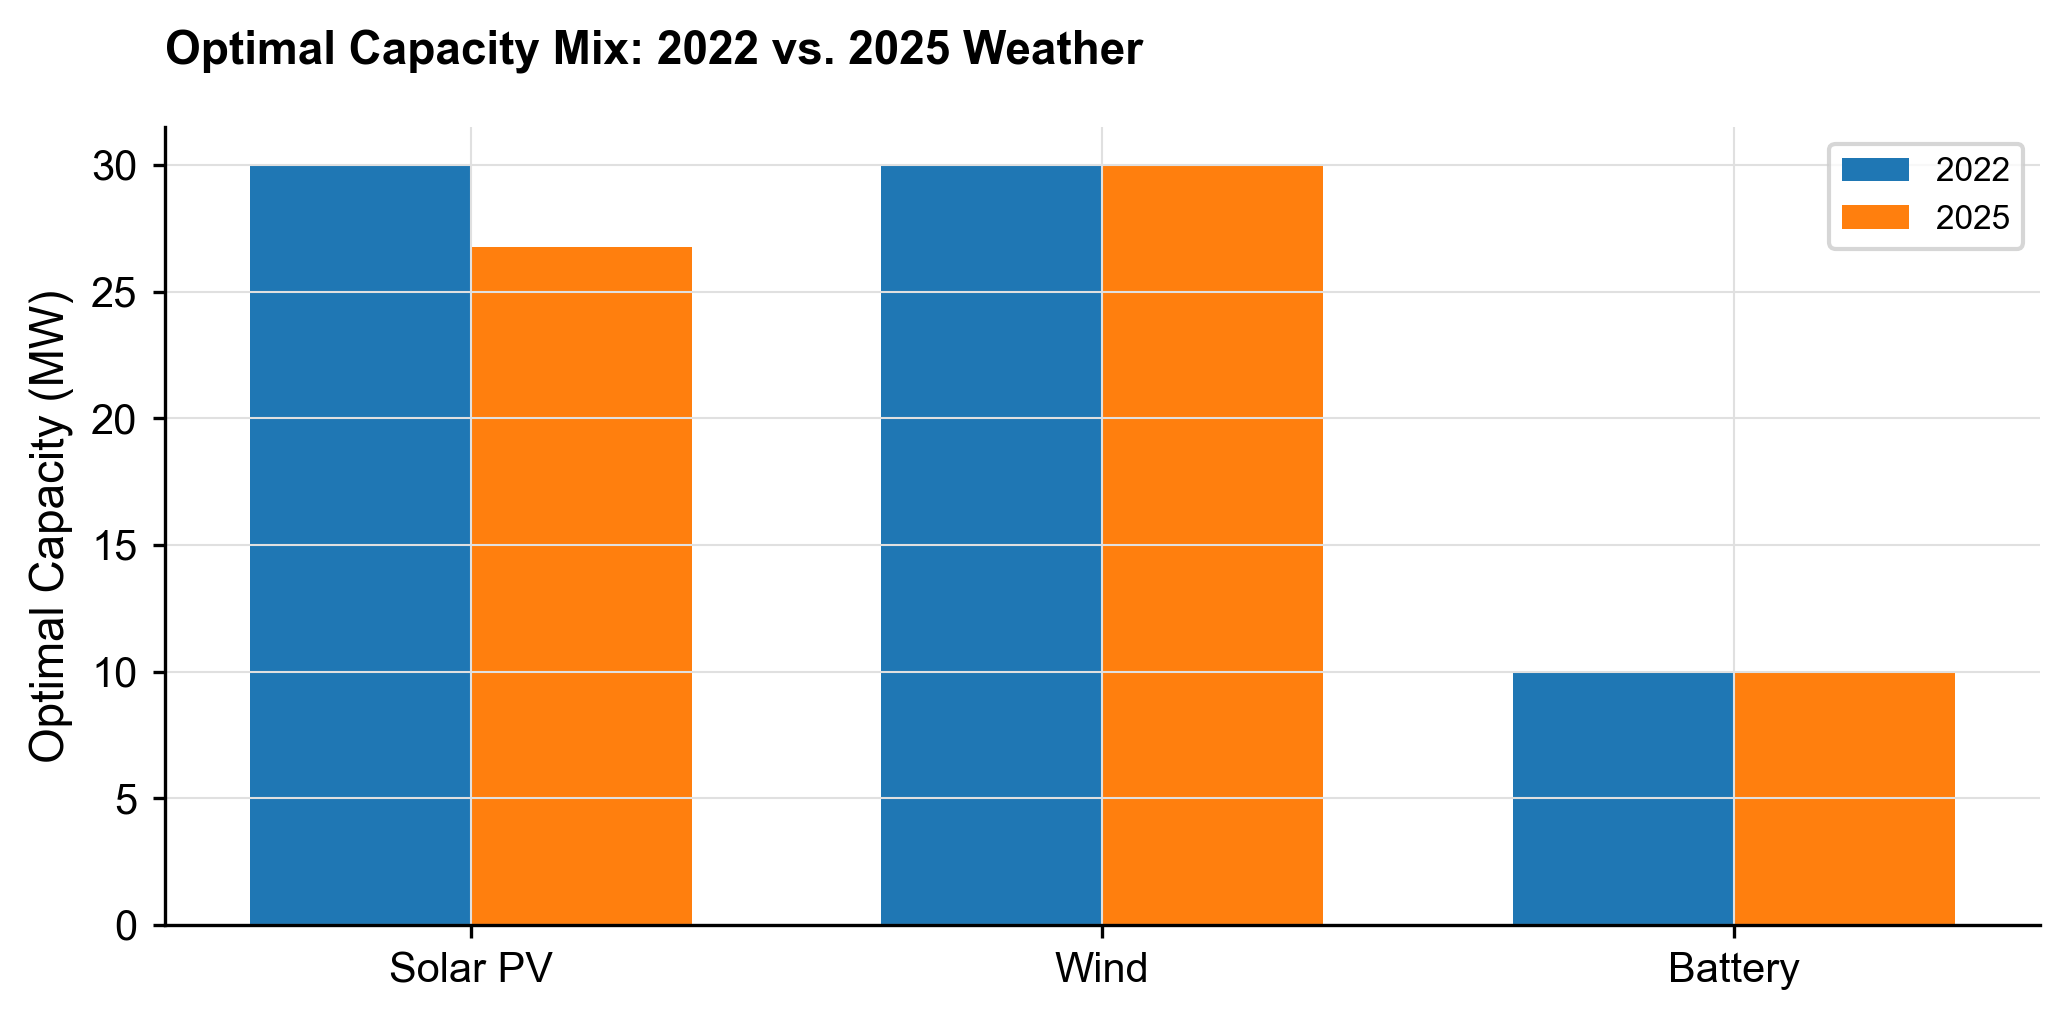


Solar capacity shift, first year -> second year: -10.8% (-3.23 MW)
Wind capacity shift, first year -> second year: +0.0% (+0.00 MW)


In [19]:
years = [2022, 2025]
year_results = {}

for year in years:
    df_pv, df_wind, df_price = load_year_data(year)
    year_results[year] = build_and_solve(df_pv, df_wind, df_price)

comparison = pd.DataFrame(year_results).T
comparison.index.name = 'year'
print(comparison[['solar_mw', 'wind_mw', 'battery_mw', 'objective']].round(2))

# Bar chart comparing optimal capacities across the two weather years
fig, ax = plt.subplots()
techs = ['solar_mw', 'wind_mw', 'battery_mw']
tech_labels = ['Solar PV', 'Wind', 'Battery']
x = np.arange(len(techs))
width = 0.35

for i, year in enumerate(years):
    values = [year_results[year][t] for t in techs]
    ax.bar(x + (i - 0.5) * width, values, width, label=str(year))

ax.set_ylabel('Optimal Capacity (MW)')
ax.set_xticks(x)
ax.set_xticklabels(tech_labels)
ax.set_title('Optimal Capacity Mix: 2022 vs. 2025 Weather', pad=15, loc='left', fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

def format_shift(before, after, label):
    abs_change = after - before
    if before < 0.5:
        return f"{label} capacity shift, first year -> second year: {abs_change:+.2f} MW (baseline near zero, percentage not meaningful)"
    pct_change = 100 * abs_change / before
    return f"{label} capacity shift, first year -> second year: {pct_change:+.1f}% ({abs_change:+.2f} MW)"

print(f"\n{format_shift(year_results[2022]['solar_mw'], year_results[2025]['solar_mw'], 'Solar')}")
print(format_shift(year_results[2022]['wind_mw'], year_results[2025]['wind_mw'], 'Wind'))


## Cost Sensitivity: Sweeping Solar's Capital Cost

Holding the weather year fixed at 2025, the model is now re-solved repeatedly while solar's capital
cost is scaled from 70% to 130% of its base value, in 10% increments. This directly answers: if the
capital cost assumption used throughout this series turns out to be wrong by up to 30% in either
direction, how much does the optimal solar capacity actually move?


Index(['electricity_bus'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 27.82it/s]
INFO:linopy.io: Writing time: 1.42s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61323 primals, 140166 duals
Objective: -2.78e+06
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.
Index(['electricity_bus'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:lino

   multiplier  solar_mw  wind_mw  battery_mw   objective
0         0.7     30.00     30.0        10.0 -2775999.40
1         0.8     30.00     30.0        10.0 -2647579.73
2         0.9     30.00     30.0        10.0 -2519160.07
3         1.0     26.77     30.0        10.0 -2395827.07
4         1.1     22.73     30.0        10.0 -2290433.50
5         1.2     18.09     30.0        10.0 -2202944.37
6         1.3     12.08     30.0        10.0 -2136956.95


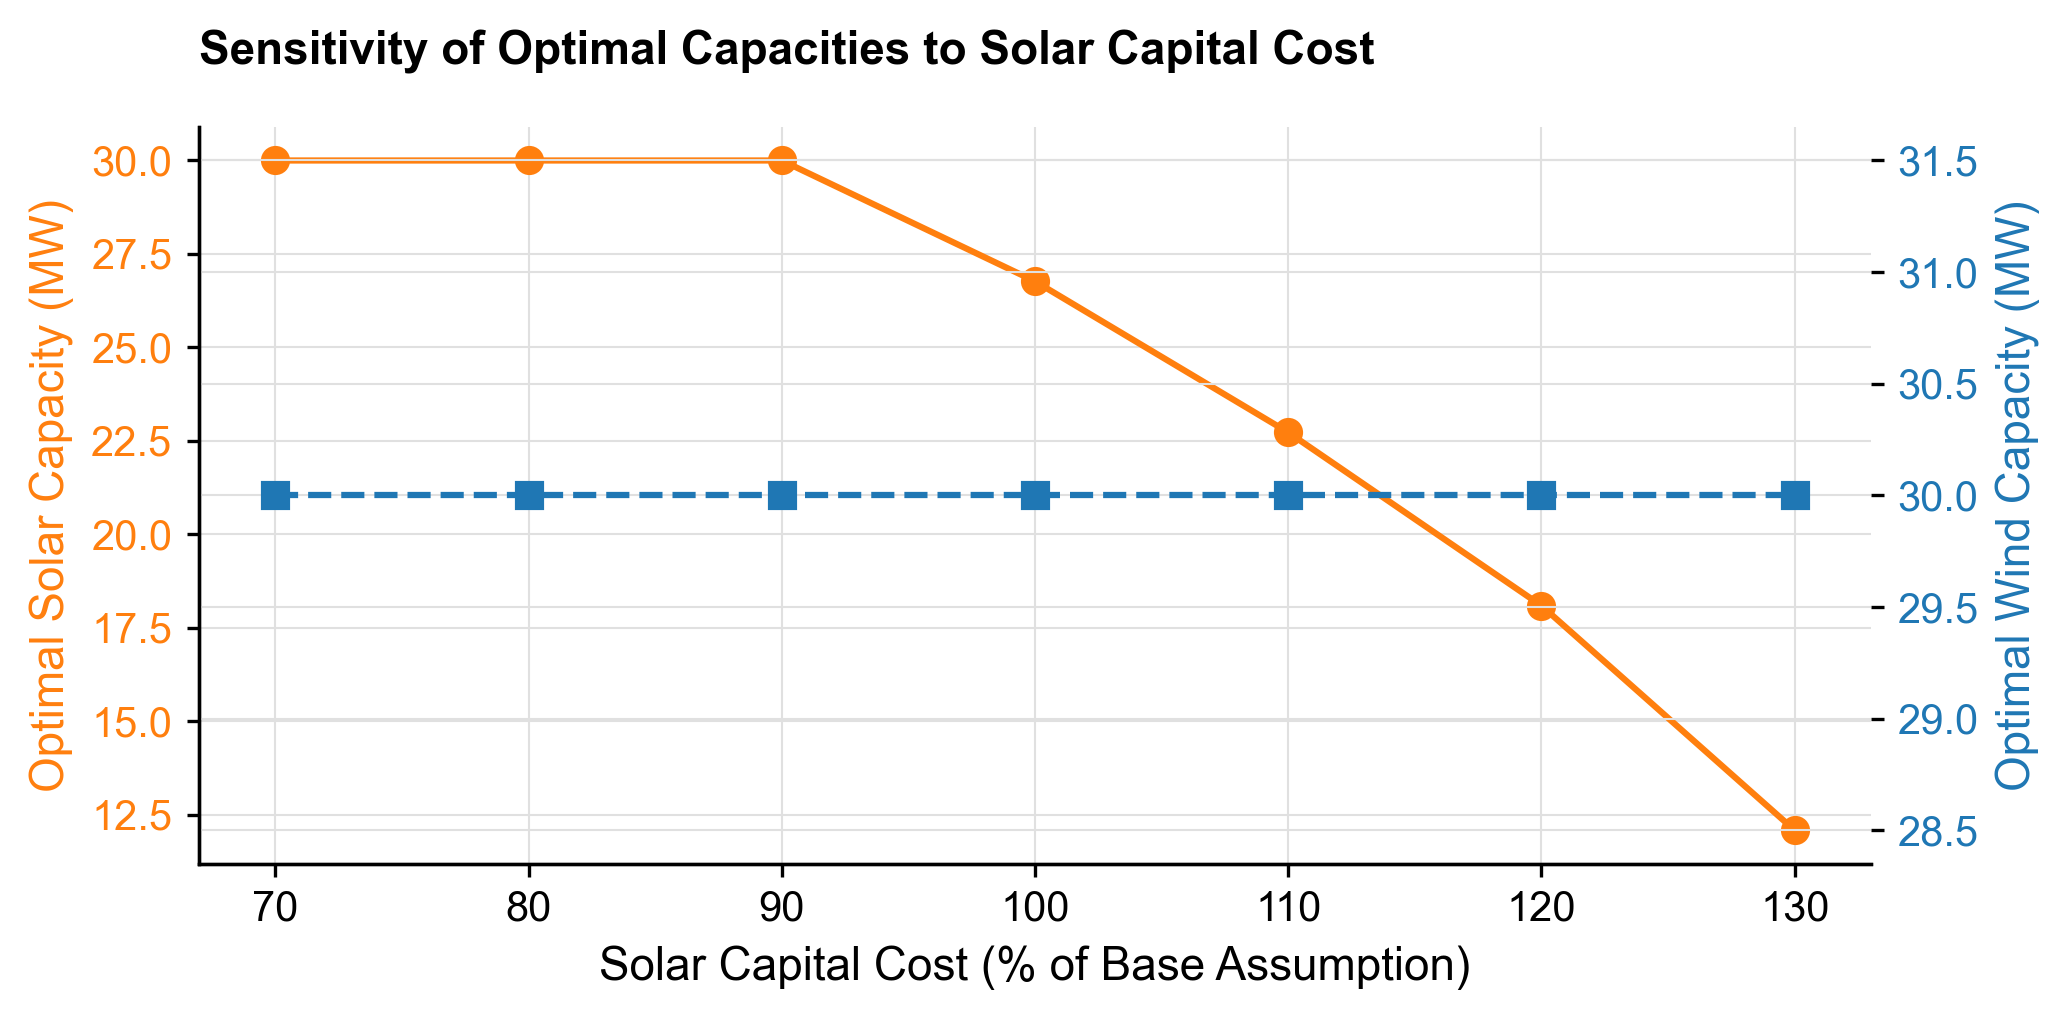


Optimal solar capacity ranges from 12.08 to 30.00 MW
across a +/-30% swing in its own capital cost assumption (range: 17.92 MW).


In [20]:
df_pv_2025, df_wind_2025, df_price_2025 = load_year_data(2025)

multipliers = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
sweep_results = []

for m in multipliers:
    result = build_and_solve(df_pv_2025, df_wind_2025, df_price_2025, solar_capital_cost_multiplier=m)
    result['multiplier'] = m
    sweep_results.append(result)

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df[['multiplier', 'solar_mw', 'wind_mw', 'battery_mw', 'objective']].round(2))

# Plot: optimal solar capacity as a function of its own capital cost assumption
fig, ax1 = plt.subplots()

ax1.plot(sweep_df['multiplier'] * 100, sweep_df['solar_mw'], color='#ff7f0e', marker='o', linewidth=1.5, label='Solar Capacity')
ax1.set_xlabel('Solar Capital Cost (% of Base Assumption)')
ax1.set_ylabel('Optimal Solar Capacity (MW)', color='#ff7f0e')
ax1.tick_params(axis='y', labelcolor='#ff7f0e')

ax2 = ax1.twinx()
ax2.plot(sweep_df['multiplier'] * 100, sweep_df['wind_mw'], color='#1f77b4', marker='s', linewidth=1.5, linestyle='--', label='Wind Capacity')
ax2.set_ylabel('Optimal Wind Capacity (MW)', color='#1f77b4')
ax2.tick_params(axis='y', labelcolor='#1f77b4')

ax1.set_title('Sensitivity of Optimal Capacities to Solar Capital Cost', pad=15, loc='left', fontweight='bold')
plt.tight_layout()
plt.show()

solar_range = sweep_df['solar_mw'].max() - sweep_df['solar_mw'].min()
print(f"\nOptimal solar capacity ranges from {sweep_df['solar_mw'].min():.2f} to {sweep_df['solar_mw'].max():.2f} MW")
print(f"across a +/-30% swing in its own capital cost assumption (range: {solar_range:.2f} MW).")
